<h2>Import Libraries</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc
)

from nltk.tokenize import word_tokenize
# Error:
"""
LookupError: 
**********************************************************************
  Resource punkt not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt/english.pickle

  Searched in:
    - 'C:\\Users\\krita/nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\share\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\lib\\nltk_data'
    - 'C:\\Users\\krita\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - ''
**********************************************************************
"""
# Source - https://stackoverflow.com/a
# Posted by alok, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-07, License - CC BY-SA 4.0
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

# Error:
"""
LookupError: 
**********************************************************************
  Resource stopwords not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load corpora/stopwords

  Searched in:
    - 'C:\\Users\\krita/nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\share\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\lib\\nltk_data'
    - 'C:\\Users\\krita\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************
"""
# nltk.download("stopwords")

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

<h2>Load Dataset</h2>

In [2]:
df = pd.read_csv("spam_mail.csv")

<h2>EDA</h2>

In [3]:
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.describe()

,Category,Masseges
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df = df.drop_duplicates()

In [6]:
df.info

<bound method DataFrame.info of      Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5169 rows x 2 columns]>

In [7]:
df.nunique()

Category       2
Masseges    5169
dtype: int64

In [8]:
df.isnull().sum()

Category    0
Masseges    0
dtype: int64

<h3>Data Cleaning</h3>

In [9]:
# Correcting the 'Masseges' typo
df.rename(columns={'Masseges': 'Messages'}, inplace=True)
df

,Category,Messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [10]:
df['message_length'] = df['Messages'].apply(lambda x: len(x))
df.head()                                             

,Category,Messages,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


<h3>Text Preprocessing</h3>

In [11]:
# preprocessing functions
def search_urls(text):
    return len(re.findall(r'https?://\S+|www\.\S+', text))
    
def search_emails(text):
    return len(re.findall(r'\S+@\S+', text)) 

def convert_to_lowercase(text):
    return text.lower()

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

def remove_extra_white_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_stopwords(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_words = [word 
                      for word in tokens if word not in stop_words]
    return " ".join(filtered_words)

def lemmatize_words(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_words)

# Function to correct spellings and typos

In [12]:
# Since emails and urls are a strong indicators for spam mail,
# features url_count and email_count are introduced.
df['url_count'] = df['Messages'].apply(lambda x: search_urls(x))
df['email_count'] = df['Messages'].apply(lambda x: search_emails(x))

In [13]:
# Applying preprocessing functions to Messages
df['Messages'] = df['Messages'].apply(lambda x: convert_to_lowercase(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_numbers(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_punctuation(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_extra_white_spaces(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_stopwords(x))
df['Messages'] = df['Messages'].apply(lambda x: lemmatize_words(x))

In [14]:
df['message_length_after_preprocessing'] = df['Messages'].apply(lambda x: len(x))
df.head(20)    

,Category,Messages,message_length,url_count,email_count,message_length_after_preprocessing
0,ham,go jurong point crazy available bugis n great ...,111,0,0,82
1,ham,ok lar joking wif u oni,29,0,0,23
2,spam,free entry wkly comp win fa cup final tkts st ...,155,0,0,106
3,ham,u dun say early hor u c already say,49,0,0,35
4,ham,nah dont think go usf life around though,61,0,0,40
5,spam,freemsg hey darling week word back id like fun...,148,0,0,82
6,ham,even brother like speak treat like aid patent,77,0,0,45
7,ham,per request melle melle oru minnaminunginte nu...,160,0,0,109
8,spam,winner valued network customer selected receiv...,158,0,0,99
9,spam,mobile month u r entitled update latest colour...,154,0,0,92


In [15]:
# Dropping unnecessary columns
df = df.drop(columns=['message_length', 'message_length_after_preprocessing'])
df.head()

,Category,Messages,url_count,email_count
0,ham,go jurong point crazy available bugis n great ...,0,0
1,ham,ok lar joking wif u oni,0,0
2,spam,free entry wkly comp win fa cup final tkts st ...,0,0
3,ham,u dun say early hor u c already say,0,0
4,ham,nah dont think go usf life around though,0,0


<h3>Label Encoding</h3>

In [16]:
# Label Encoding
category_map = {
    'ham' : 0,
    'spam' : 1
}
df['Category'] = df['Category'].map(category_map)
df.head()

,Category,Messages,url_count,email_count
0,0,go jurong point crazy available bugis n great ...,0,0
1,0,ok lar joking wif u oni,0,0
2,1,free entry wkly comp win fa cup final tkts st ...,0,0
3,0,u dun say early hor u c already say,0,0
4,0,nah dont think go usf life around though,0,0


<h3>Word Cloud Visualization</h3>

In [17]:
# Word Cloud Generation
spam_messages = df[df['Category'] == 1]['Messages'].str.cat(sep=' ')
ham_messages = df[df['Category'] == 0]['Messages'].str.cat(sep=' ')

# Word Cloud for Spam
spam_wordcloud = WordCloud(width=1600, height=1000, 
                           background_color='white', 
                           min_font_size=10).generate(spam_messages)

# Word Cloud for Ham
ham_wordcloud = WordCloud(width=1600, height=1000, 
                          background_color='white', 
                          min_font_size=10).generate(ham_messages)

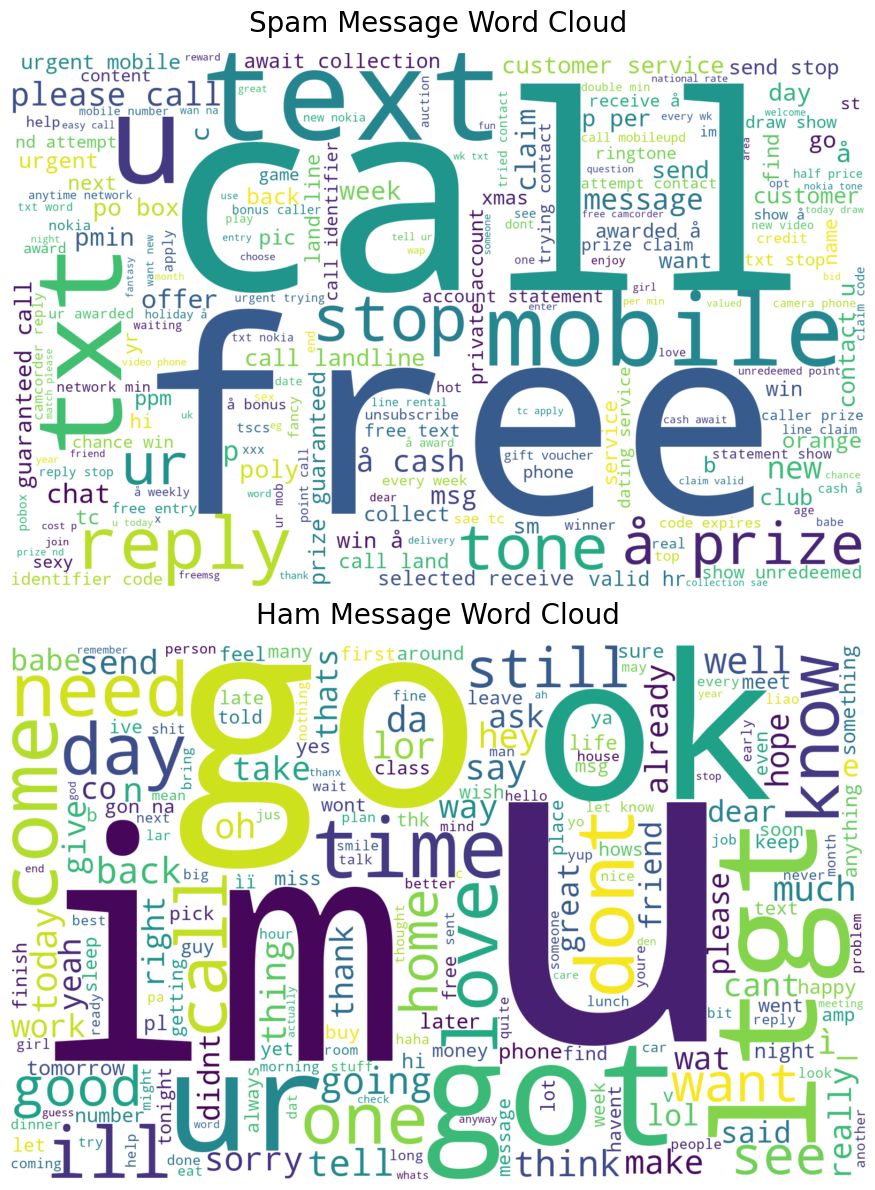

In [18]:
# Word Cloud Visualization
plt.figure(figsize=(15, 12))

# Plot Spam Word Cloud
plt.subplot(2, 1, 1)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Spam Message Word Cloud', 
          fontsize=20,                
          pad=15)                
plt.axis('off')

# Plot Ham Word Cloud
plt.subplot(2, 1, 2)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Ham Message Word Cloud', 
          fontsize=20, 
          pad=15)
plt.axis('off')

plt.tight_layout()
plt.show()

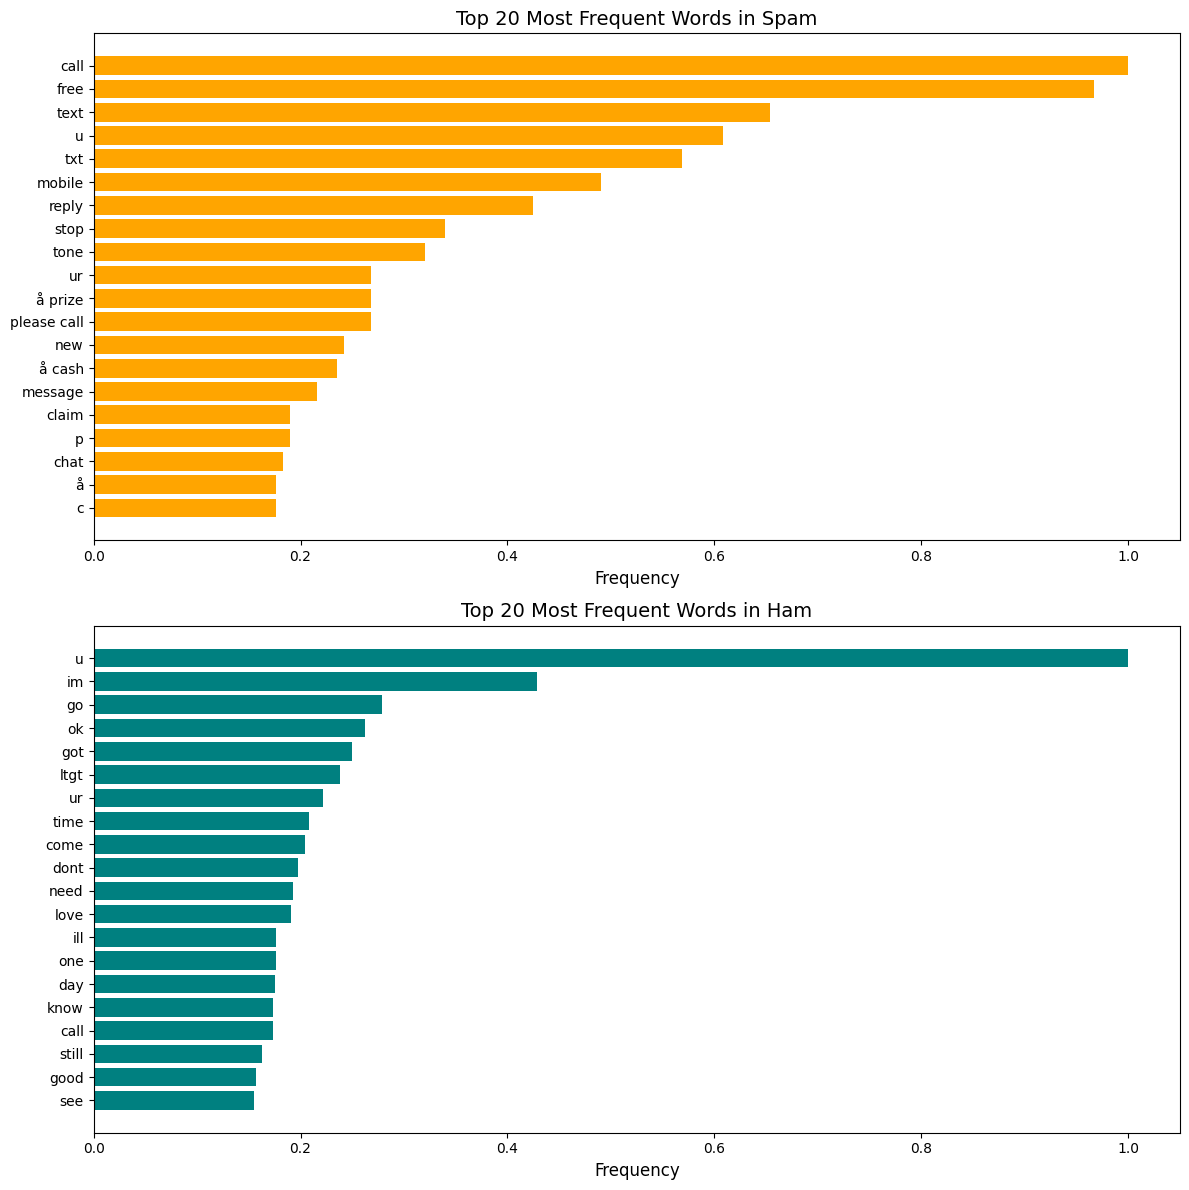

In [19]:
# extracting word frequencies from word cloud
spam_word_freq = spam_wordcloud.words_
ham_word_freq = ham_wordcloud.words_

spam_freq_df = pd.DataFrame(
    list(spam_word_freq.items()), 
    columns=['Word', 'Frequency']
).sort_values('Frequency', ascending=False)

ham_freq_df = pd.DataFrame(
    list(ham_word_freq.items()), 
    columns=['Word', 'Frequency']
).sort_values('Frequency', ascending=False)

plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.barh(spam_freq_df['Word'].head(20)[::-1], 
         spam_freq_df['Frequency'].head(20)[::-1], 
         color='orange')
plt.xlabel('Frequency', fontsize=12)
plt.title(f'Top 20 Most Frequent Words in Spam', fontsize=14)

plt.subplot(2, 1, 2)
plt.barh(ham_freq_df['Word'].head(20)[::-1], 
         ham_freq_df['Frequency'].head(20)[::-1], 
         color='teal')
plt.xlabel('Frequency', fontsize=12)
plt.title(f'Top 20 Most Frequent Words in Ham', fontsize=14)

plt.tight_layout()
plt.show()

<h3>Vectorization</h3>

In [20]:
# Vectorization
features = df['Messages']

# TF-IDF Values Calculation
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(features)
features = result.toarray()

<h3>Train Test Split</h3>

In [21]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(features, df['Category'].values, test_size=0.3, random_state = 42)

In [22]:
# Checking for presence of class imbalance
count_target = np.unique(y_train, return_counts = True)
count_target

(array([0, 1], dtype=int64), array([3185,  433], dtype=int64))

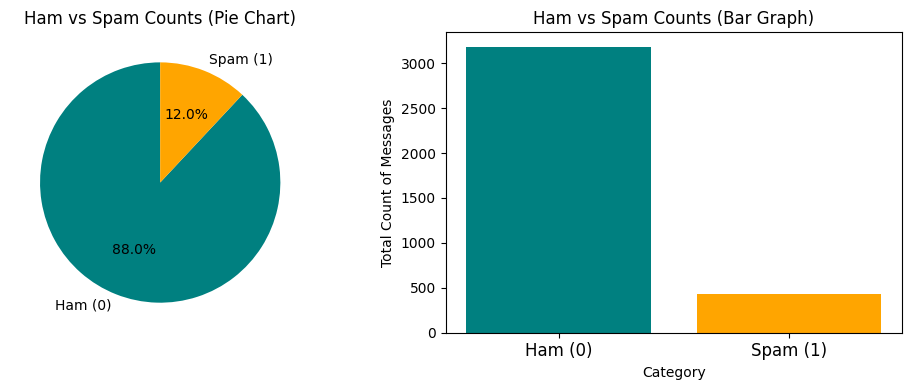

In [23]:
# Graphical Representation
index, count = count_target
plt.figure(figsize = (10, 4))

# Pie Chart for Class Distribution
plt.subplot(1, 2, 1)

# Calculate percentages
total = sum(count)
percentages = [c/total*100 for c in count]

plt.pie(
    count, 
    labels = ['Ham (0)', 'Spam (1)'], 
    autopct='%1.1f%%',
    startangle=90,
    colors = ['teal', 'orange'],
)
plt.title("Ham vs Spam Counts (Pie Chart)")

# Bar Graph for Class Distribution
plt.subplot(1, 2, 2)
plt.bar(
    index, 
    count, 
    color=['teal', 'orange']
)
plt.xticks(index, ['Ham (0)', 'Spam (1)'], fontsize=12)
plt.title("Ham vs Spam Counts (Bar Graph)")
plt.xlabel("Category")
plt.ylabel("Total Count of Messages")

plt.tight_layout()
plt.show()

<h3>Class Imbalance Analysis</h3>

In [24]:
# Ham Messages: 3372 i.e., ~88% of the dataset
# Spam Messages: 528 i.e., ~12% of the dataset
# There is an imbalance of class where ham messages heavily dominates the dataset.
# Even if the model predicts all messages as ham, it will have an accuracy of ~88%.

<h3>Resampling Data for Class Imbalance</h3>

In [25]:
# Function to plot class distribution after resampling
def plot_resampling_results(y_resampled, title):
    index, count = np.unique(y_resampled, return_counts = True)
    
    total = sum(count)
    percentages = [c/total*100 for c in count]
    
    plt.pie(
        count, 
        labels = ['Ham (0)', 'Spam (1)'], 
        autopct='%1.1f%%',
        startangle=90,
        colors = ['teal', 'orange'],
    )
    plt.title(title)
    plt.show()

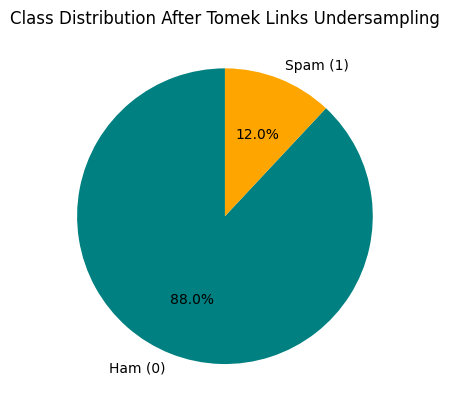

In [26]:
# Solving Class Imbalance with TomekLinks Undersampling
tomek = TomekLinks()
X_tl_train, y_tl_train = tomek.fit_resample(X_train, y_train)
plot_resampling_results(y_tl_train, 'Class Distribution After Tomek Links Undersampling')

In [27]:
# Due to absence of borderline data, no change was observed in the dataset.

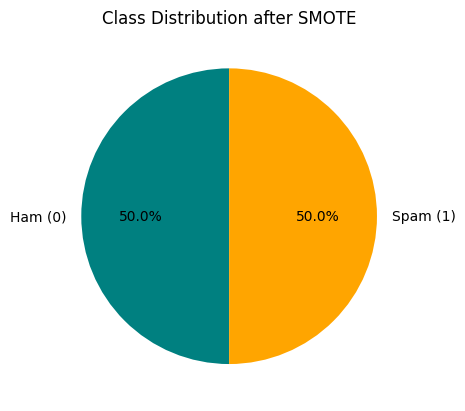

In [28]:
# Solving Class Imbalance with SMOTE 
smote = SMOTE(random_state = 123)
X_smote_train, y_smote_train = smote.fit_resample(X_train, y_train)
plot_resampling_results(y_smote_train, 'Class Distribution after SMOTE')

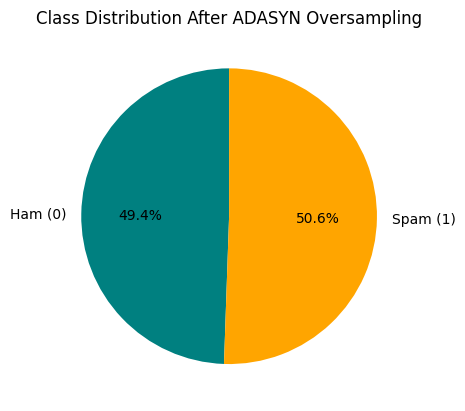

In [29]:
# Solving Class Imbalance with ADASYN oversampling
adasyn = ADASYN(random_state = 123)
X_adasyn_train, y_adasyn_train = adasyn.fit_resample(X_train, y_train)
plot_resampling_results(y_adasyn_train, 'Class Distribution After ADASYN Oversampling')

<h3>Model Selection</h3>

In [30]:
# model evaluation functions
def evaluate_model(y_test, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    cf_matrix = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba, average = None)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    pr_auc_curve = precision_recall_curve(y_test, y_pred_proba)

    evaluation_metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Confusion_Matrix': cf_matrix,
        'roc_auc_score': roc_auc,
        'roc_curve': (fpr, tpr, thresholds),
        'pr_auc_curve': pr_auc_curve
    }
    
    return evaluation_metrics

def display_metrics(evaluation_metrics):
    print(f'Accuracy: {evaluation_metrics.get("Accuracy")}')
    print(f'Precision: {evaluation_metrics.get("Precision")}')
    print(f'Recall: {evaluation_metrics.get("Recall")}')
    print(f'F1 Score: {evaluation_metrics.get("F1_Score")}')
    print(f'ROC AUC Score: {evaluation_metrics.get("roc_auc_score")}')
    
    class_labels = ['Ham (0)', 'Spam (1)'] 

    plt.figure(figsize=(8, 18))
    
    # Confusion Matrix
    plt.subplot(3, 1, 1)
    sns.heatmap(
        evaluation_metrics.get("Confusion_Matrix"), 
        annot=True,          
        fmt='d',             
        cmap='Blues',        
        xticklabels = class_labels, 
        yticklabels=class_labels  
    )
    
    plt.title('Confusion Matrix')

    # roc_auc_curve
    fpr, tpr, thresholds = evaluation_metrics.get('roc_curve')
    plt.subplot(3, 1, 2)
    plt.plot(
        fpr, 
        tpr,
        color = 'orange',
        lw = 2,
        label = f"ROC Curve (AUC = {evaluation_metrics.get('roc_auc_score')})"
    )
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity/Recall)')
    plt.title('ROC Curve')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, linestyle = 'dotted', color='black')

    # pr_auc curve
    precision, recall, thresholds = evaluation_metrics.get('pr_auc_curve')
    pr_auc_score = auc(recall, precision)

    plt.subplot(3, 1, 3)
    plt.plot(
        recall, 
        precision, 
        label=f'Precision-Recall Curve (AUC = {pr_auc_score})'
    )
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True, linestyle = 'dotted', color='black')

    plt.tight_layout()
    plt.show()

<h3>Multinomial Naive Bayes Classifier</h3>

In [31]:
# Multinomial Naive Bayes Model
def train_MNB_model(X_train, y_train, X_test):
    mnb_model = MultinomialNB()
    mnb_model.fit(X_train, y_train)
    y_pred = mnb_model.predict(X_test)
    y_pred_proba = mnb_model.predict_proba(X_test)[:, 1]
    
    return y_pred, y_pred_proba

Accuracy: 0.9542230818826564
Precision: 0.796812749003984
Recall: 0.9090909090909091
F1 Score: 0.8492569002123143
ROC AUC Score: 0.9827641554538624


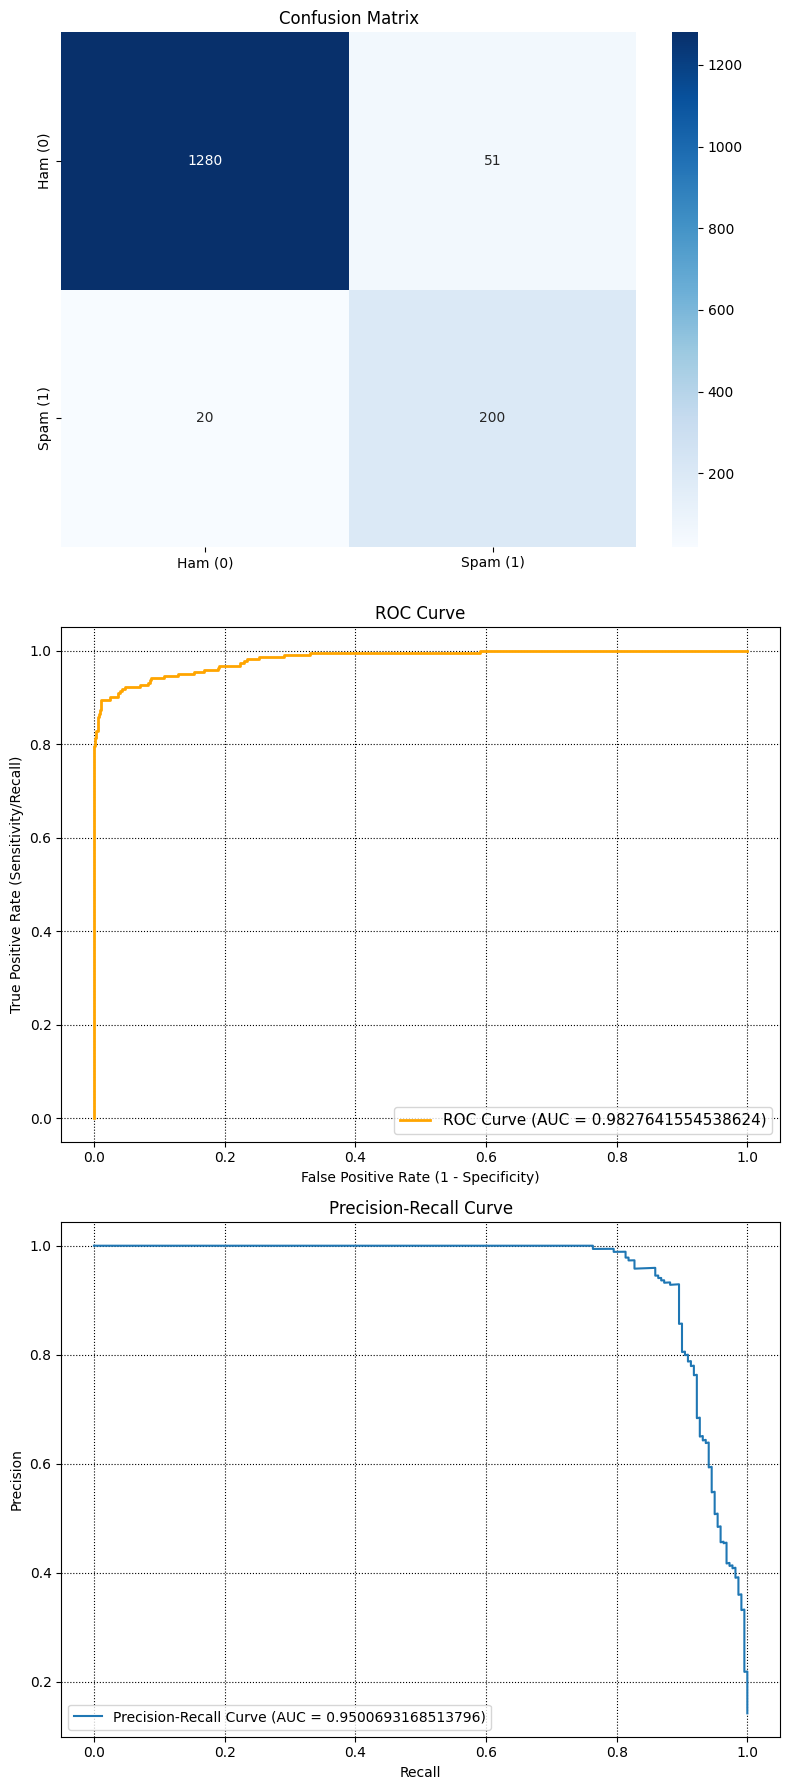

In [32]:
# Training and Evaluation on resampled data using SMOTE
smote_MNB_y_pred, smote_MNB_y_pred_proba = train_MNB_model(
    X_smote_train, 
    y_smote_train, 
    X_test
)
smote_MNB_metrics = evaluate_model(
    y_test, 
    smote_MNB_y_pred,
    smote_MNB_y_pred_proba
)
display_metrics(smote_MNB_metrics)

Accuracy: 0.9497098646034816
Precision: 0.7669172932330827
Recall: 0.9272727272727272
F1 Score: 0.8395061728395061
ROC AUC Score: 0.9851786080185779


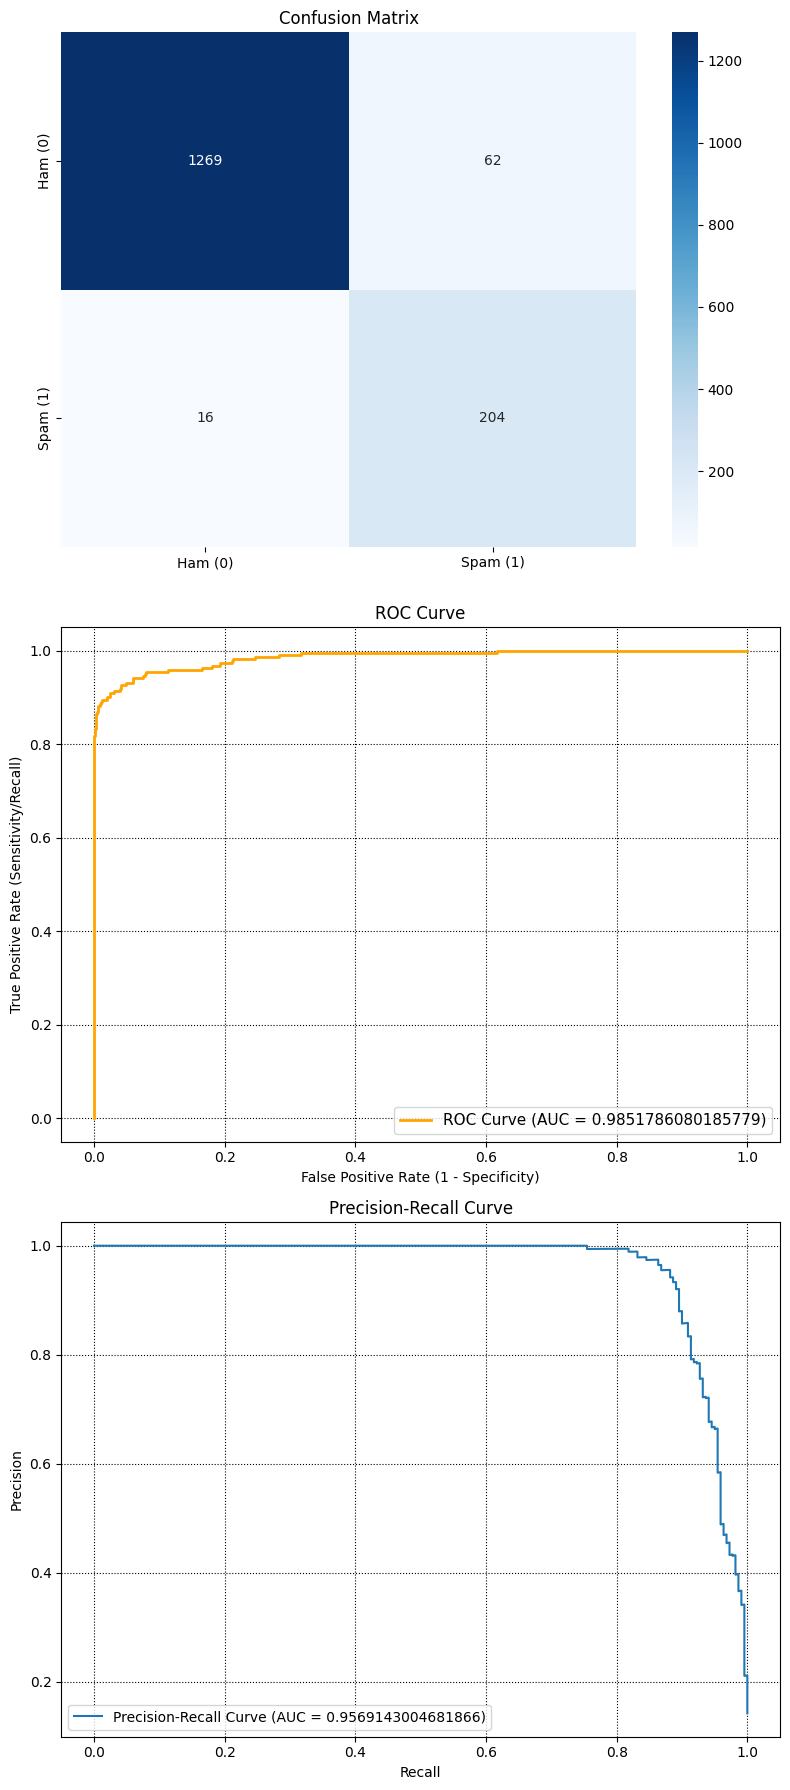

In [33]:
# Training and Evaluation on resampled data using ADASYN Oversampling
adasyn_MNB_y_pred, adasyn_MNB_y_pred_proba = train_MNB_model(
    X_adasyn_train, 
    y_adasyn_train, 
    X_test
)
adasyn_MNB_metrics = evaluate_model(
    y_test, 
    adasyn_MNB_y_pred,
    adasyn_MNB_y_pred_proba
)
display_metrics(adasyn_MNB_metrics)

<h3>Support Vector Machine Classifier</h3>

In [34]:
# SVM Model
def train_SVM_model(X_train, y_train, X_test):
    svm_model = SVC(
        kernel = 'linear',
        probability = True,
        random_state = 42
    )
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    y_pred_proba = svm_model.predict_proba(X_test)[:, 1]

    return y_pred, y_pred_proba

Accuracy: 0.9716312056737588
Precision: 0.9356435643564357
Recall: 0.8590909090909091
F1 Score: 0.8957345971563981
ROC AUC Score: 0.9823884980534118


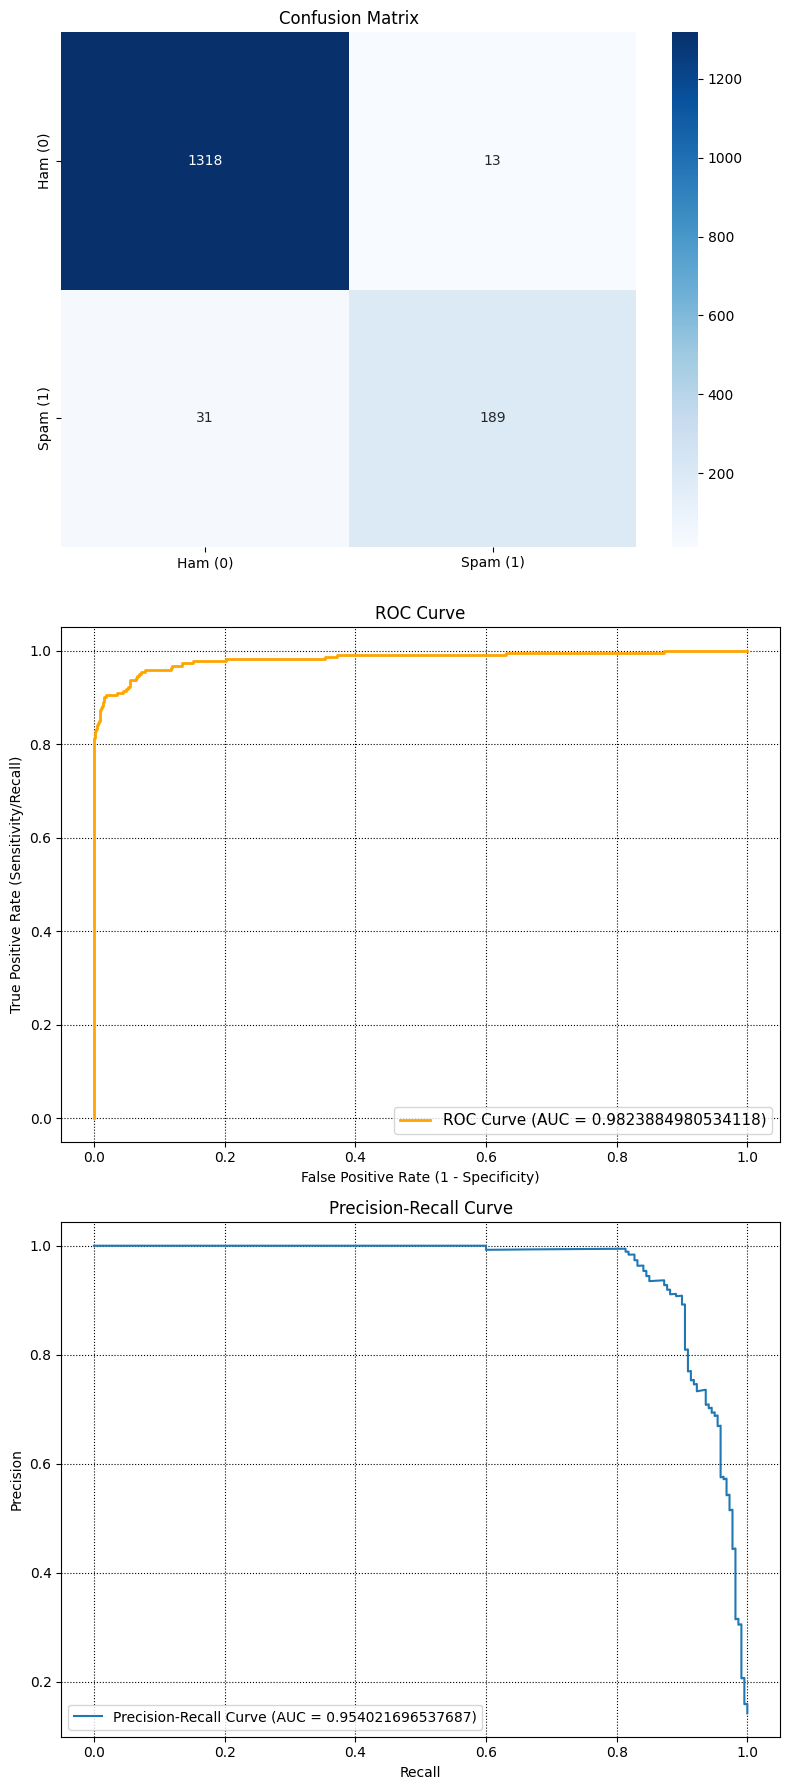

In [35]:
# Training and Evaluation on resampled data using SMOTE
smote_SVM_y_pred, smote_SVM_y_pred_proba = train_SVM_model(
    X_smote_train, 
    y_smote_train, 
    X_test
)
smote_SVM_metrics = evaluate_model(
    y_test, 
    smote_SVM_y_pred,
    smote_SVM_y_pred_proba
)
display_metrics(smote_SVM_metrics)

Accuracy: 0.9716312056737588
Precision: 0.9356435643564357
Recall: 0.8590909090909091
F1 Score: 0.8957345971563981
ROC AUC Score: 0.9825694966190834


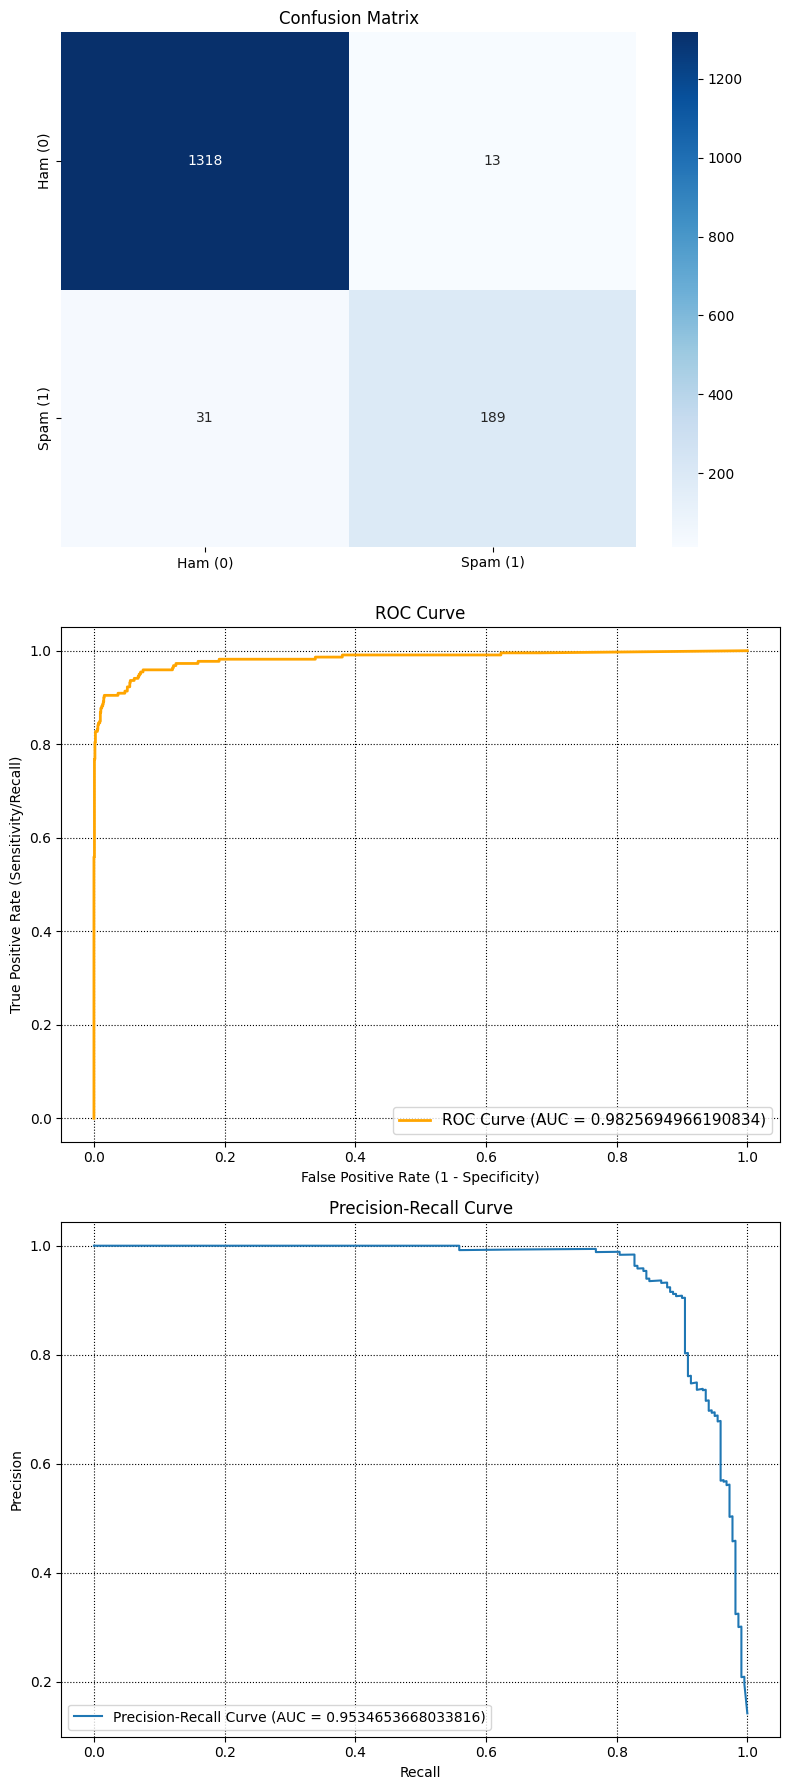

In [36]:
# Training and Evaluation on resampled data using ADASYN
adasyn_SVM_y_pred, adasyn_SVM_y_pred_proba = train_SVM_model(
    X_adasyn_train, 
    y_adasyn_train, 
    X_test
)
adasyn_SVM_metrics = evaluate_model(
    y_test, 
    adasyn_SVM_y_pred,
    adasyn_SVM_y_pred_proba
)
display_metrics(adasyn_SVM_metrics)

<h3>Hyperparameter Tuning</h3>

In [37]:
# Hyperparameter Tuning for Multinomial Naive Bayes Classifier
# parameter grid for Multinomial Naive Bayes Classifier
multinomialNB_param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0],
    'fit_prior': [True, False],
    'class_prior': [None, [0.5, 0.5], [0.8, 0.2], [0.9, 0.1]]
} 

In [38]:
multinomialNB_grid_search = GridSearchCV(
    MultinomialNB(),
    param_grid = multinomialNB_param_grid,
    cv = 5,
    n_jobs = -1
)
multinomialNB_grid_search.fit(X_smote_train, y_smote_train)

GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0,
                                   5.0, 10.0],
                         'class_prior': [None, [0.5, 0.5], [0.8, 0.2],
                                         [0.9, 0.1]],
                         'fit_prior': [True, False]})

In [39]:
multinomialNB_grid_search.best_params_

{'alpha': 0.0001, 'class_prior': [0.9, 0.1], 'fit_prior': True}

Accuracy: 0.965183752417795
Precision: 0.8878504672897196
Recall: 0.8636363636363636
F1 Score: 0.8755760368663594
ROC AUC Score: 0.9781606447647018


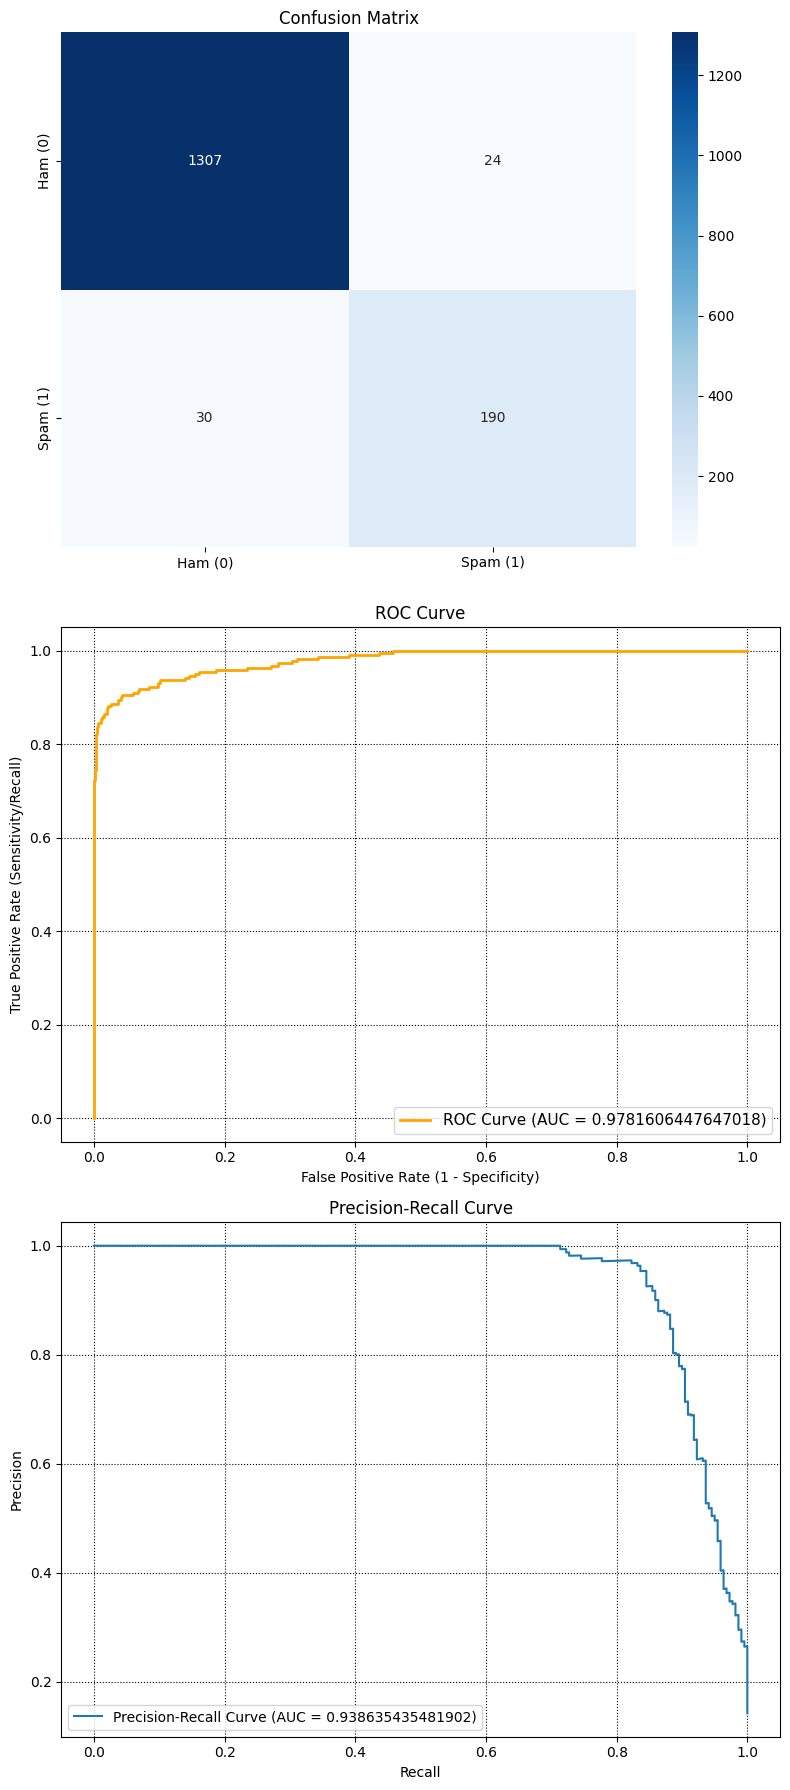

In [40]:
# multinomialNB_best_model = multinomialNB_grid_search.best_estimator_
# multinomialNB_y_pred_tuned = multinomialNB_best_model.predict(X_test)
# accuracy_score(y_test, svm_y_pred_tuned)

# using the best param/model to predict spam
tuned_mnb_model = MultinomialNB(
    alpha = 0.0001,
    class_prior = [0.9, 0.1],
    fit_prior = True
)
tuned_mnb_model.fit(X_train, y_train)
mnb_y_pred_tuned = tuned_mnb_model.predict(X_test)
mnb_y_pred_proba_tuned = tuned_mnb_model.predict_proba(X_test)[:, 1]

mnb_tuned_metrics = evaluate_model(y_test, mnb_y_pred_tuned, mnb_y_pred_proba_tuned)
display_metrics(mnb_tuned_metrics)

In [41]:
# Hyperparameter Tuning for SVM Classifier
# parameter grid for SVM Classifier
svm_param_grid = {
    'C': [10, 100, 1000],
    'gamma': [10, 100, 1000],
    'kernel': ['linear'],
    'degree': [1]
}

In [42]:
# fitting 
svm_grid_search = GridSearchCV(
    SVC(), 
    param_grid = svm_param_grid, 
    cv = 5,
    verbose = 3,
    n_jobs = -1
)
svm_grid_search.fit(X_adasyn_train, y_adasyn_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [10, 100, 1000], 'degree': [1],
                         'gamma': [10, 100, 1000], 'kernel': ['linear']},
             verbose=3)

In [43]:
svm_grid_search.best_params_
# {'C': 100, 'degree': 1, 'gamma': 100, 'kernel': 'linear'}
# {'C': 100, 'degree': 1, 'gamma': 100, 'kernel': 'linear'}

{'C': 100, 'degree': 1, 'gamma': 10, 'kernel': 'linear'}

Accuracy: 0.9748549323017408
Precision: 0.9641025641025641
Recall: 0.8545454545454545
F1 Score: 0.906024096385542
ROC AUC Score: 0.9826548733010041


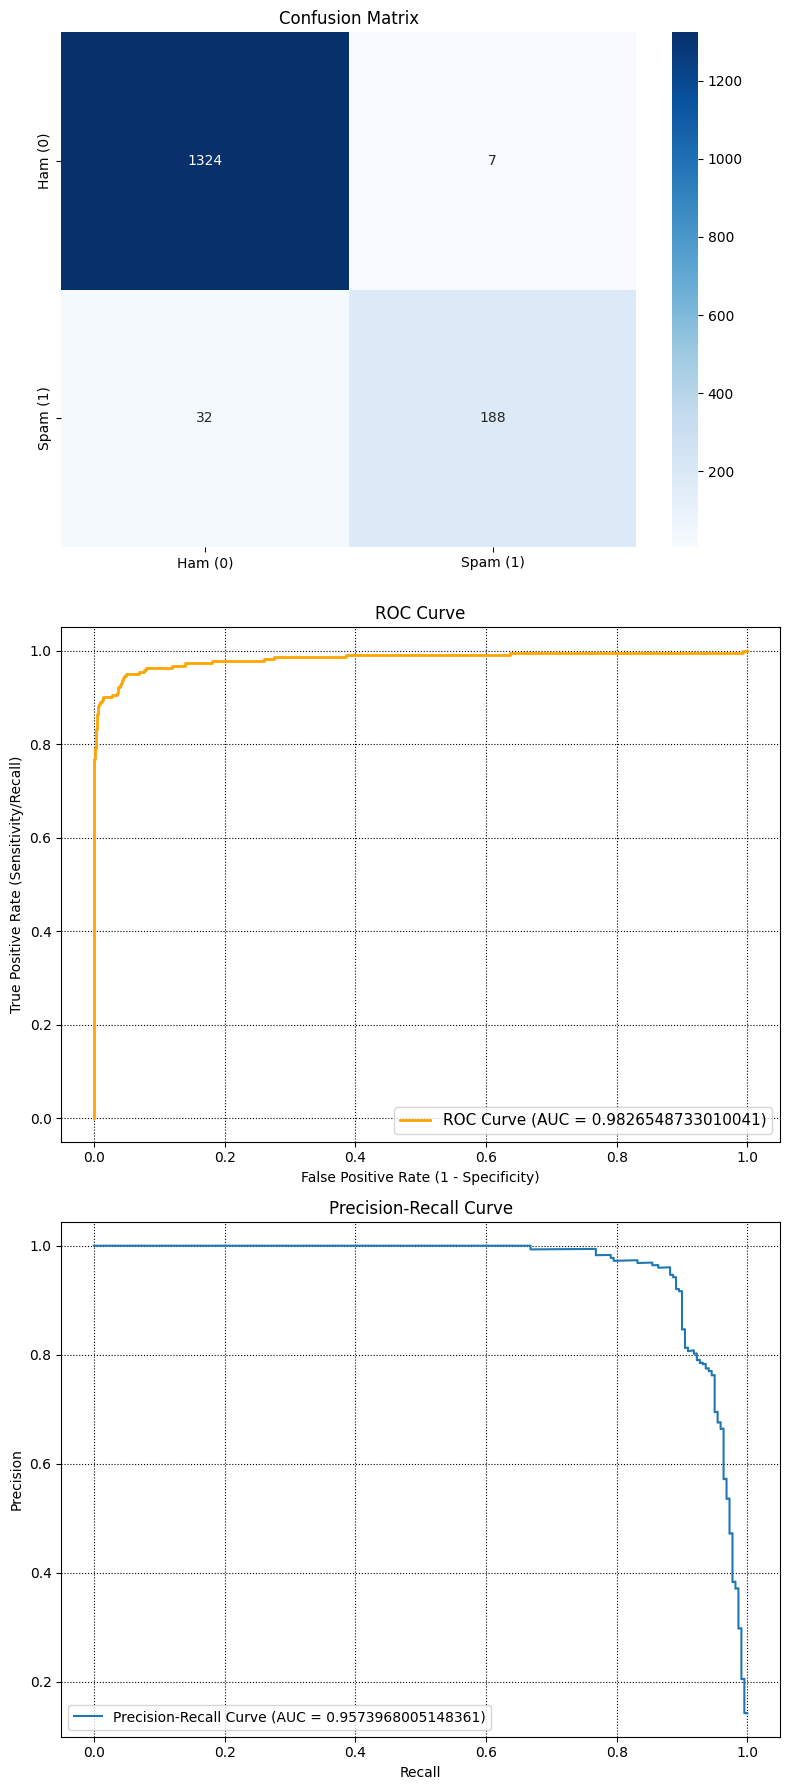

In [44]:
# svm_best_model = svm_grid_search.best_estimator_
# svm_y_pred_tuned = svm_best_model.predict(X_test)
# accuracy_score(y_test, svm_y_pred_tuned)

# using the best param/model to predict spam
svm_tuned_model = SVC(
        kernel = 'linear',
        C = 100,
        degree = 1,
        gamma = 100,
        probability = True,
        random_state = 42
    )
svm_tuned_model.fit(X_train, y_train)
svm_y_pred_tuned = svm_tuned_model.predict(X_test)
svm_y_pred_proba_tuned = svm_tuned_model.predict_proba(X_test)[:, 1]
svm_tuned_metrics = evaluate_model(y_test, svm_y_pred_tuned, svm_y_pred_proba_tuned)
display_metrics(svm_tuned_metrics)

<h3>Results</h3>

In [45]:
# function to plot comparisions of model
def plot_comparisions(metrics_a:dict, metrics_b:dict, metrics_c:dict):
    # Key metrices grouped bar plot
    x = np.arange(4)
    keys_to_include = {'Accuracy', 'Precision', 'Recall', 'F1_Score'}
    # y1 = [metrics_a[key] for key in keys_to_include if key in metrics_a]
    # y2 = [metrics_b[key] for key in keys_to_include if key in metrics_b]
    # y3 = [metrics_c[key] for key in keys_to_include if key in metrics_c]
    y1 = [metrics_a['Accuracy'], metrics_a['Precision'], metrics_a['Recall'], metrics_a['F1_Score']]
    y2 = [metrics_b['Accuracy'], metrics_b['Precision'], metrics_b['Recall'], metrics_b['F1_Score']]
    y3 = [metrics_c['Accuracy'], metrics_c['Precision'], metrics_c['Recall'], metrics_c['F1_Score']]
    
    width = 0.2
    plt.figure(figsize=(12, 20))
    
    plt.subplot(3, 1, 1)
    plt.bar(x-0.2, y1, width, color='skyblue')
    plt.bar(x, y2, width, color='bisque')
    plt.bar(x+0.2, y3, width, color='lightgray')
    plt.grid(True, linestyle = 'dotted', color='black')
    plt.xticks(x, ['Accuracy', 'Precision', 'Recall', 'F1 Score'])
    plt.xlabel("Metrics")
    plt.ylabel("Scores")
    plt.title('Key Metrics Comparision')
    plt.legend(
        [metrics_a['model_title'], 
         metrics_b['model_title'], 
         metrics_c['model_title']],
        bbox_to_anchor=(0.5, -0.1), 
        loc='upper center', 
    )

    # roc_auc_curve
    plt.subplot(3, 1, 2)
    fpr_a, tpr_a, thresholds_a = metrics_a.get('roc_curve')
    fpr_b, tpr_b, thresholds_b = metrics_b.get('roc_curve')
    fpr_c, tpr_c, thresholds_c = metrics_c.get('roc_curve')
    plt.plot(
        fpr_a, 
        tpr_a,
        color = 'teal',
        lw = 2
    )
    plt.plot(
        fpr_b, 
        tpr_b,
        color = 'orange',
        lw = 2
    )
    plt.plot(
        fpr_c, 
        tpr_c,
        color = 'gray',
        lw = 2
    )
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity/Recall)')
    plt.title('ROC Curve Comparision')
    plt.legend(
        [f'{metrics_a["model_title"]} | ROC AUC Score: {metrics_a["roc_auc_score"]}', 
        f'{metrics_b["model_title"]} | ROC AUC Score: {metrics_b["roc_auc_score"]}', 
        f'{metrics_c["model_title"]} | ROC AUC Score: {metrics_c["roc_auc_score"]}'],
        loc='lower right'
    )
    plt.grid(True, linestyle = 'dotted', color='black')

    # precision-recall curve
    precision_a, recall_a, thresholds_a = metrics_a.get('pr_auc_curve')
    pr_auc_score_a = auc(recall_a, precision_a)

    precision_b, recall_b, thresholds_b = metrics_b.get('pr_auc_curve')
    pr_auc_score_b = auc(recall_b, precision_b)

    precision_c, recall_c, thresholds_c = metrics_c.get('pr_auc_curve')
    pr_auc_score_c = auc(recall_c, precision_c)
    
    plt.subplot(3, 1, 3)
    plt.plot(
        recall_a, 
        precision_a,
        color = 'teal',
        lw = 2
    )
    plt.plot(
        recall_b, 
        precision_b,
        color = 'orange',
        lw = 2
    )
    plt.plot(
        recall_c, 
        precision_c,
        color = 'gray',
        lw = 2
    )
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparision')
    plt.legend(
        [f'{metrics_a["model_title"]} | Precision-Recall Score: {pr_auc_score_a}', 
        f'{metrics_b["model_title"]} | Precision-Recall: {pr_auc_score_b}', 
        f'{metrics_c["model_title"]} | Precision-Recall: {pr_auc_score_c}'],
        loc='lower right'
    )
    plt.grid(True, linestyle = 'dotted', color='black')
    
    plt.tight_layout()
    plt.show()

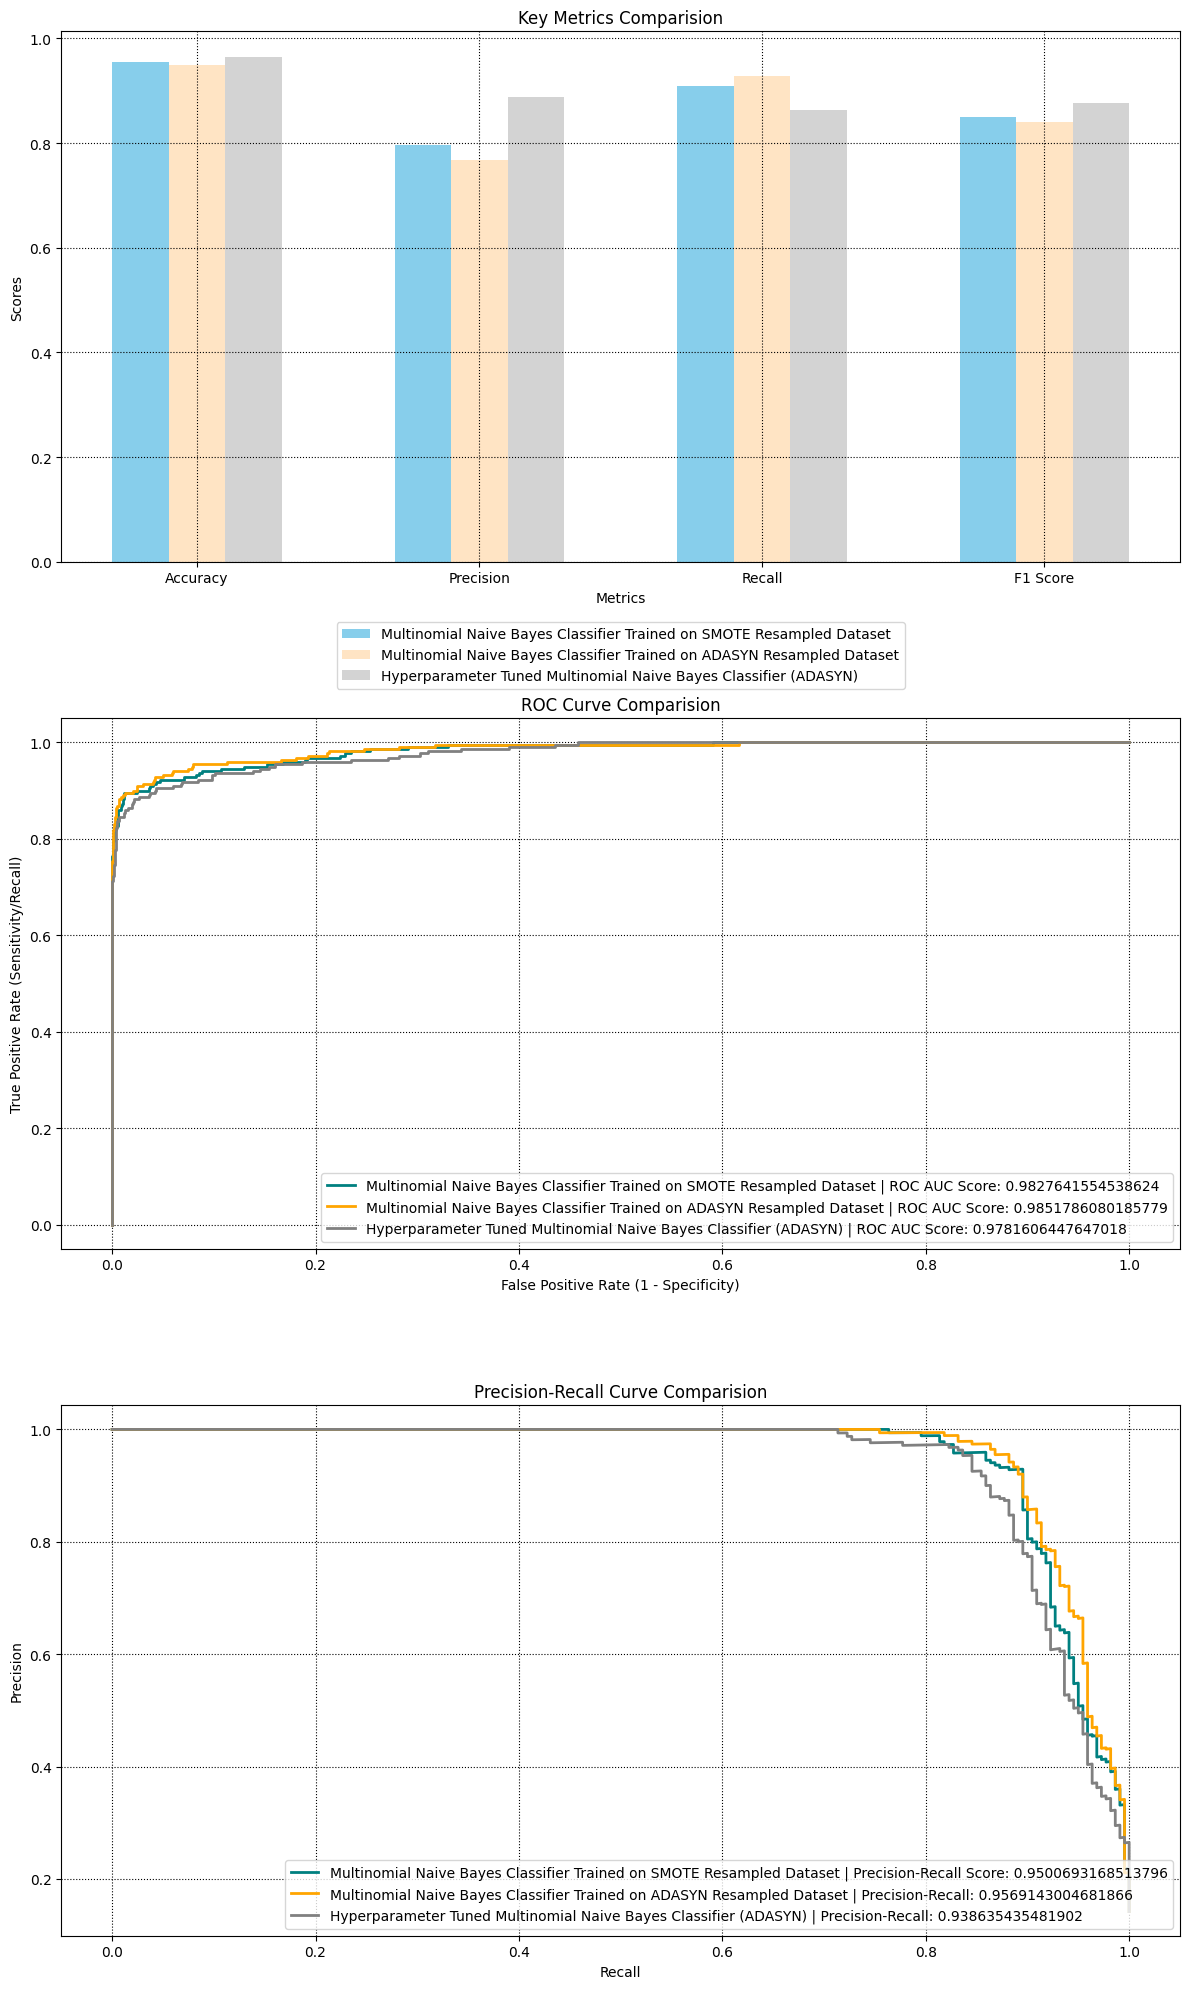

In [46]:
# Comparing Multinomial Naive Bayes Classifier with smote resampled dataset, 
# adasyn resampled dataset and hyperparameter tuned adasyn resampled dataset
smote_MNB_metrics['model_title'] = 'Multinomial Naive Bayes Classifier Trained on SMOTE Resampled Dataset'
adasyn_MNB_metrics['model_title'] = 'Multinomial Naive Bayes Classifier Trained on ADASYN Resampled Dataset'
mnb_tuned_metrics['model_title'] = 'Hyperparameter Tuned Multinomial Naive Bayes Classifier (ADASYN)'

plot_comparisions(smote_MNB_metrics, adasyn_MNB_metrics, mnb_tuned_metrics)

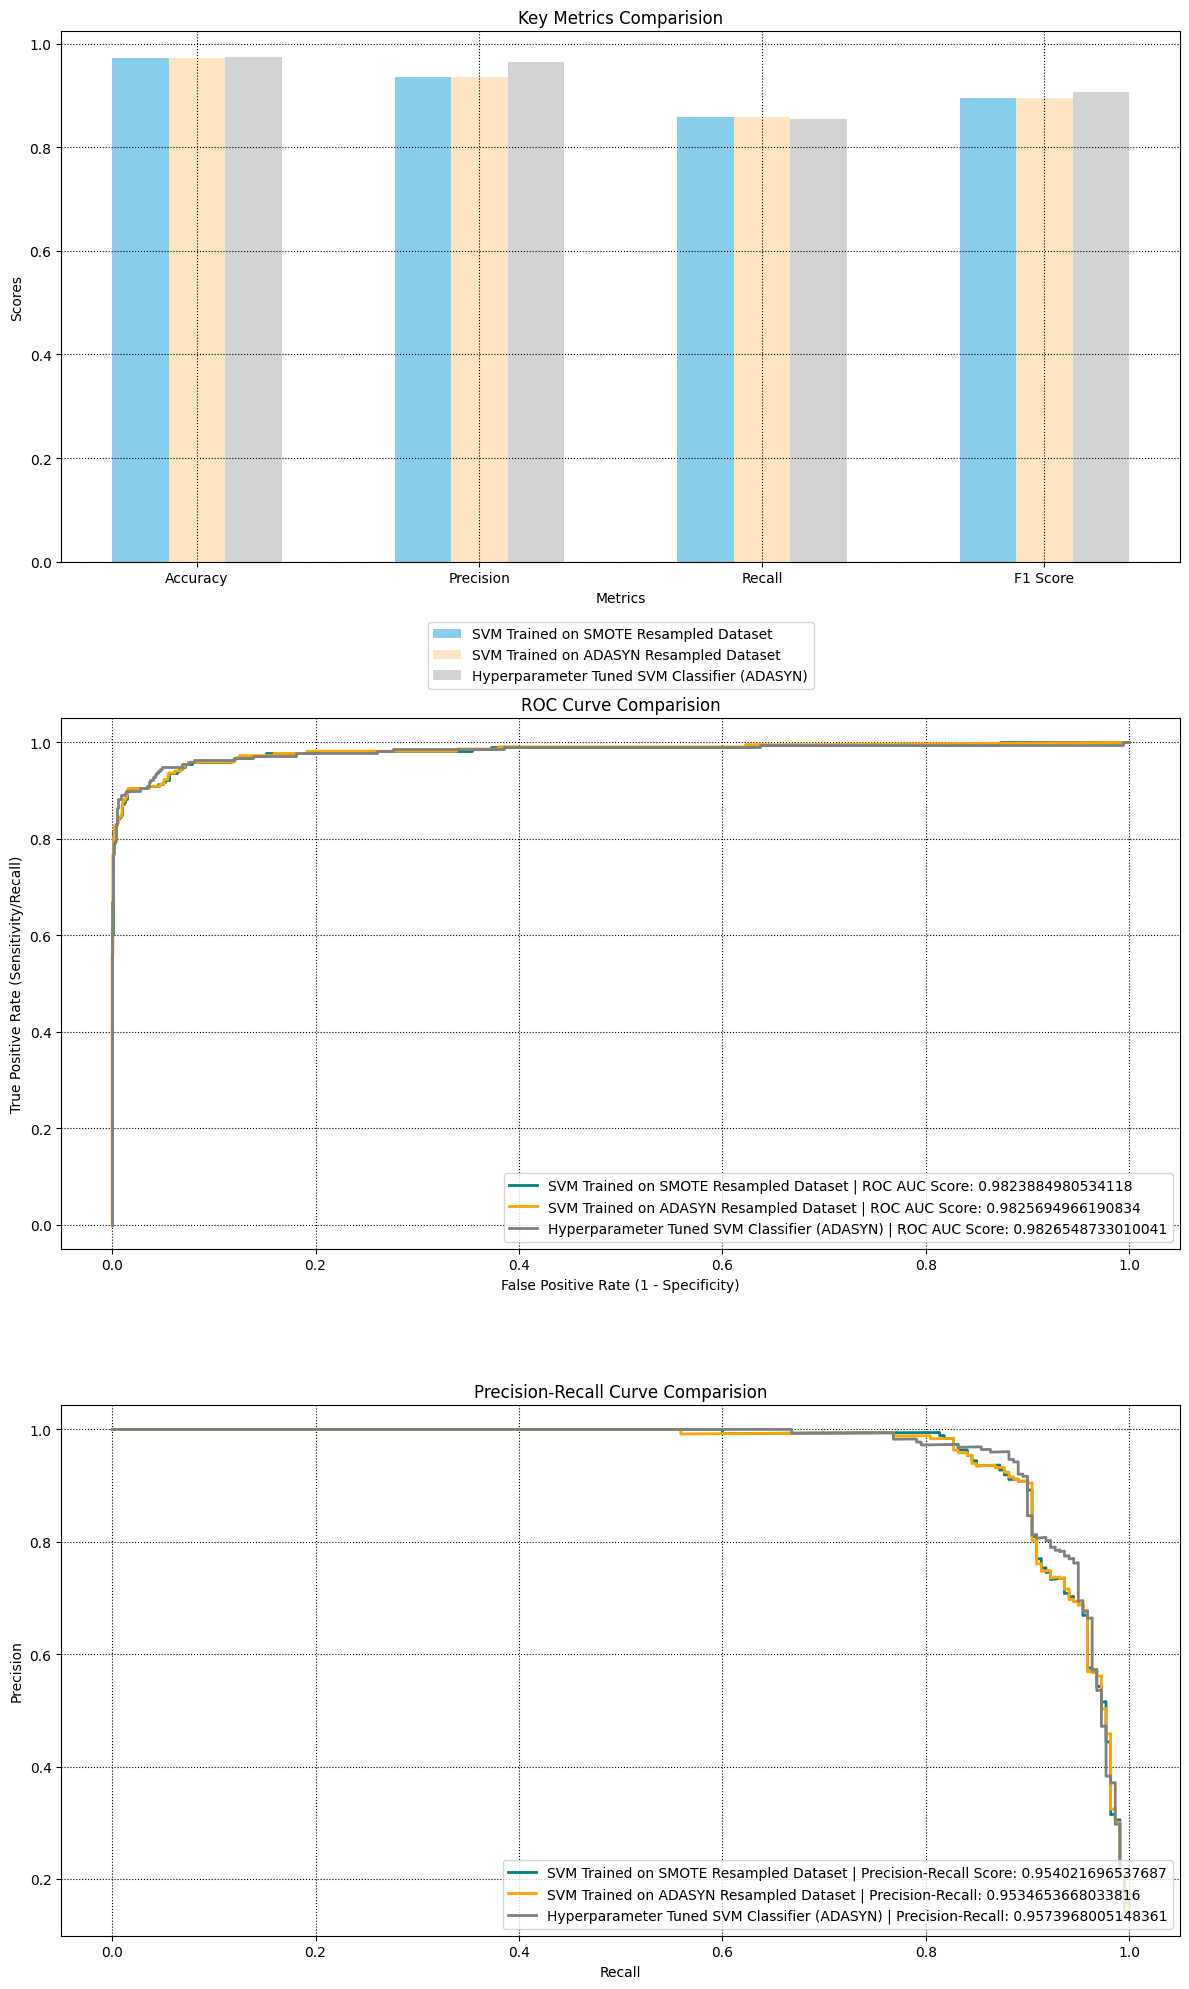

In [47]:
# Comparing SVM Classifier with smote resampled dataset, 
# adasyn resampled dataset and hyperparameter tuned adasyn resampled dataset
smote_SVM_metrics['model_title'] = 'SVM Trained on SMOTE Resampled Dataset'
adasyn_SVM_metrics['model_title'] = 'SVM Trained on ADASYN Resampled Dataset'
svm_tuned_metrics['model_title'] = 'Hyperparameter Tuned SVM Classifier (ADASYN)'

plot_comparisions(smote_SVM_metrics, adasyn_SVM_metrics, svm_tuned_metrics)

In [48]:
# function to plot comparisions of model
def plot_two_comparisions(metrics_a:dict, metrics_b:dict):
    # Key metrices grouped bar plot
    x = np.arange(4)
    keys_to_include = {'Accuracy', 'Precision', 'Recall', 'F1_Score'}
    y1 = [metrics_a['Accuracy'], metrics_a['Precision'], metrics_a['Recall'], metrics_a['F1_Score']]
    y2 = [metrics_b['Accuracy'], metrics_b['Precision'], metrics_b['Recall'], metrics_b['F1_Score']]
    
    width = 0.2
    plt.figure(figsize=(12, 20))
    
    plt.subplot(3, 1, 1)
    plt.bar(x-0.2, y1, width, color='skyblue')
    plt.bar(x, y2, width, color='bisque')
    plt.grid(True, linestyle = 'dotted', color='black')
    plt.xticks(x, ['Accuracy', 'Precision', 'Recall', 'F1 Score'])
    plt.xlabel("Metrics")
    plt.ylabel("Scores")
    plt.title('Key Metrics Comparision')
    plt.legend(
        [metrics_a['model_title'], 
         metrics_b['model_title']],
        bbox_to_anchor=(0.5, -0.1), 
        loc='upper center', 
    )

    # roc_auc_curve
    plt.subplot(3, 1, 2)
    fpr_a, tpr_a, thresholds_a = metrics_a.get('roc_curve')
    fpr_b, tpr_b, thresholds_b = metrics_b.get('roc_curve')
    plt.plot(
        fpr_a, 
        tpr_a,
        color = 'teal',
        lw = 2
    )
    plt.plot(
        fpr_b, 
        tpr_b,
        color = 'orange',
        lw = 2
    )
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity/Recall)')
    plt.title('ROC Curve Comparision')
    plt.legend(
        [f'{metrics_a["model_title"]} | ROC AUC Score: {metrics_a["roc_auc_score"]}', 
        f'{metrics_b["model_title"]} | ROC AUC Score: {metrics_b["roc_auc_score"]}'],
        loc='lower right'
    )
    plt.grid(True, linestyle = 'dotted', color='black')

    # precision-recall curve
    precision_a, recall_a, thresholds_a = metrics_a.get('pr_auc_curve')
    pr_auc_score_a = auc(recall_a, precision_a)

    precision_b, recall_b, thresholds_b = metrics_b.get('pr_auc_curve')
    pr_auc_score_b = auc(recall_b, precision_b)
    
    plt.subplot(3, 1, 3)
    plt.plot(
        recall_a, 
        precision_a,
        color = 'teal',
        lw = 2
    )
    plt.plot(
        recall_b, 
        precision_b,
        color = 'orange',
        lw = 2
    )
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparision')
    plt.legend(
        [f'{metrics_a["model_title"]} | Precision-Recall Score: {pr_auc_score_a}', 
        f'{metrics_b["model_title"]} | Precision-Recall: {pr_auc_score_b}'],
        loc='lower right'
    )
    plt.grid(True, linestyle = 'dotted', color='black')
    
    plt.tight_layout()
    plt.show()

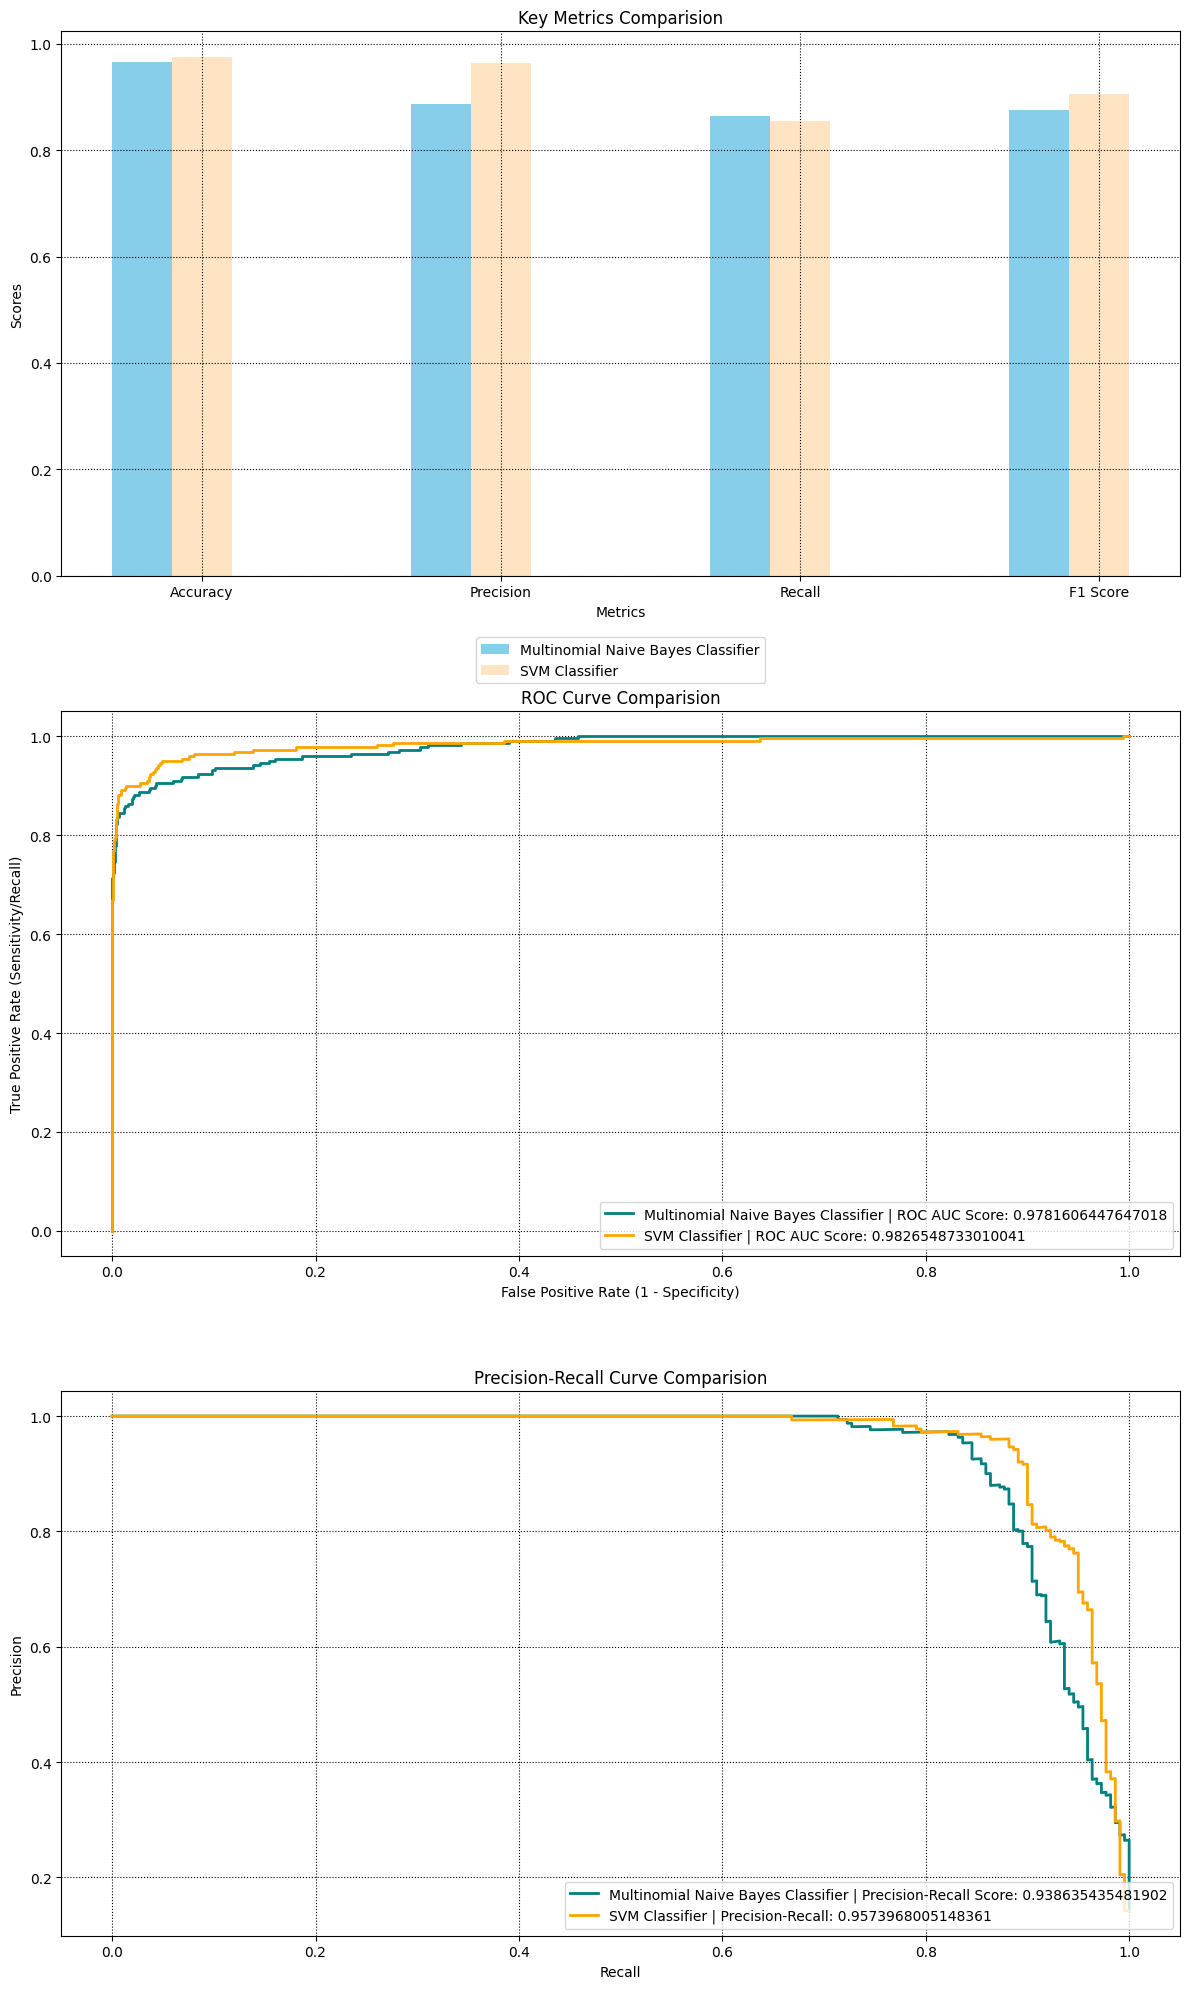

In [49]:
# Comparing SVM Classifier and Multinomial NB Classifier
mnb_tuned_metrics['model_title'] = 'Multinomial Naive Bayes Classifier'
svm_tuned_metrics['model_title'] = 'SVM Classifier'

plot_two_comparisions(mnb_tuned_metrics, svm_tuned_metrics)

In [88]:
# Testing with foreign data
foreign_test_data = [
    "Win $5000 now! Click facebo0k.com/win-cash-free",
    "Congratulations! You've won a $1000 gift card. Claim your prize now at this link lucky-lottery/win-cash-free.",
    "URGENT: Please call this number to stop mobile charges. Reply STOP to opt out.",
    "URGENT: Your account has been suspended. Click here to restore access immediately.",
    "Your account is hacked. Reset password: secure-login123.com",
    "Meeting moved to 3 PM today in room 205",
    "Hey, lunch tomorrow? Text me back",
    "Mom called, call her when you're free",
    "Think Mark Think!",
    "Hey Sarah, are we still on for dinner at Mario's tonight? I made reservations for 7:30. Also, do you want to see the new Marvel movie after? Text me when you get this!"
]

# Text Preprocessing
foreign_test_data = list(map(convert_to_lowercase, foreign_test_data))
foreign_test_data = list(map(remove_numbers, foreign_test_data))
foreign_test_data = list(map(remove_punctuation, foreign_test_data))
foreign_test_data = list(map(remove_extra_white_spaces, foreign_test_data))
foreign_test_data = list(map(remove_stopwords, foreign_test_data))
foreign_test_data = list(map(lemmatize_words, foreign_test_data))

# Vectorization
# TF-IDF Values Calculation
cleaned_foreign_test_data = tfidf.transform(foreign_test_data)

In [89]:
# Function for prediction visualization
def visualize_predictions(model):
    prediction = model.predict(cleaned_foreign_test_data.toarray())
    probabilities = model.predict_proba(cleaned_foreign_test_data.toarray())

    confidence = np.max(probabilities, axis=1)
    x_positions = np.arange(len(prediction))
    
    width = 0.8
    plt.figure(figsize=(8, 6))
    
    plt.subplot(1, 1, 1)
    # Create bars for confidence scores
    bars = plt.bar(x_positions, confidence, width, 
                   color=['teal' if p == 0 else 'orange' for p in prediction])
    
    # Customize the plot
    plt.grid(True, linestyle='dotted', color='gray', alpha=0.7)
    plt.xticks(x_positions, [f'Msg {i+1}' for i in range(len(prediction))], rotation=45)
    plt.xlabel("Message Number")
    plt.ylabel("Confidence Score")
    plt.title('Prediction Confidence Scores')
    plt.ylim([0, 1.1])
    
    # Add confidence values on top of bars
    for bar, conf in zip(bars, confidence):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{conf:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

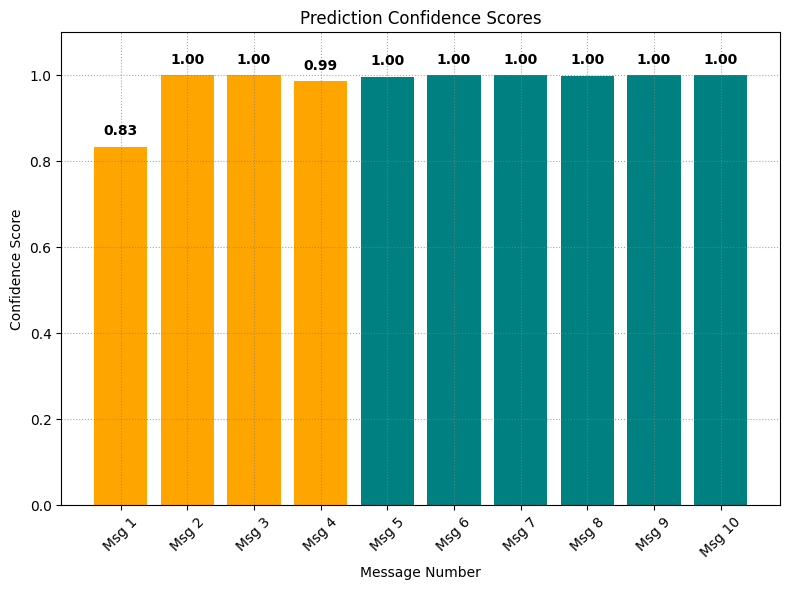

In [90]:
visualize_predictions(tuned_mnb_model)

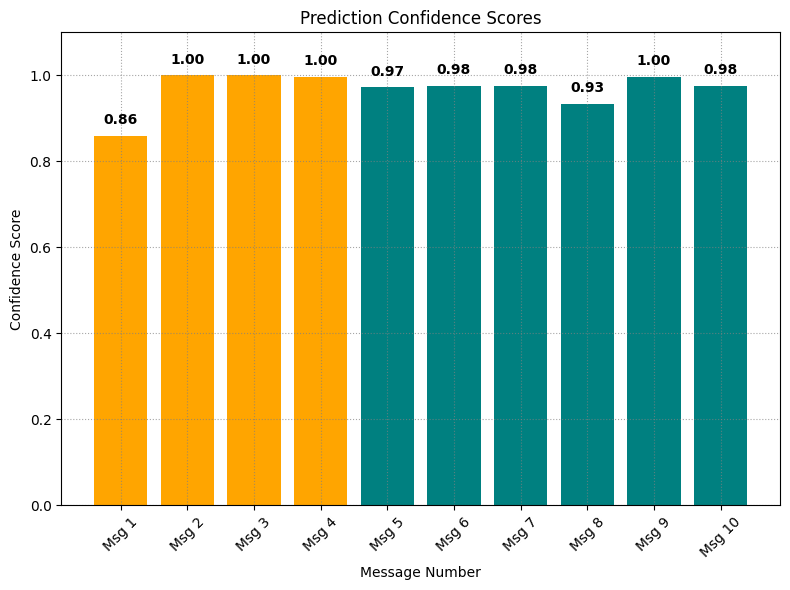

In [91]:
visualize_predictions(svm_tuned_model)